# In-class Problem

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from CBFV import composition

from sklearn.preprocessing import StandardScaler

# Fit a linear regression model
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNet

In [2]:
# ---------------------------------------------------------------------------
# Why this version of the worksheet is different
# ---------------------------------------------------------------------------
# In the original worksheet we trained on all ~44,000 compounds with 264 CBFV
# descriptors as features. That is roughly 170 rows per feature -- plenty for
# ordinary least squares (OLS) to already be stable. With that much data,
# Ridge, Lasso and ElasticNet all came out within about 0.01 of plain linear
# regression's R^2, which doesn't tell much of a story.
#
# In real materials discovery you rarely get 44,000 labelled compounds. DFT
# calculations and experiments are expensive, so a realistic training set
# might be a few hundred materials -- while a rich CBFV descriptor set still
# gives you hundreds of columns. That is exactly the regime where Ridge,
# Lasso and ElasticNet earn their keep: p (features) comparable to, or even
# larger than, n (samples), with many correlated descriptors.
#
# This worksheet uses the same data source and the same featurization as
# before, but deliberately trains on a small, realistic-sized subset while
# still scoring on a large held-out test set, so the comparison stays honest.
# N_TRAIN is a single knob near the top -- change it and re-run to watch the
# story shift as the sample size grows (try 150, then 300, then 2000).

In [3]:
data=pd.read_csv("data/lec05-HW_formation_energy.csv")
data.head()

,Unnamed: 0,jid,spg_number,spg_symbol,formula,formation_energy_peratom,func,optb88vdw_bandgap
0,1,JVASP-90856,129,P4/nmm,TiCuSiAs,-0.42762,OptB88vdW,0.000
1,2,JVASP-86097,221,Pm-3m,DyB6,-0.41596,OptB88vdW,0.000
2,3,JVASP-64906,119,I-4m2,Be2OsRu,0.04847,OptB88vdW,0.000
3,4,JVASP-98225,14,P2_1/c,KBi,-0.44140,OptB88vdW,0.472
4,5,JVASP-10,164,P-3m1,VSe2,-0.71026,OptB88vdW,0.000


In [4]:
len(data)

55716

In [5]:
data=data.dropna(axis=0,how='any')
len(data)

55714

In [6]:
data=data.drop(['Unnamed: 0','optb88vdw_bandgap','func','spg_symbol','spg_number','jid'],axis=1)
data.head()

,formula,formation_energy_peratom
0,TiCuSiAs,-0.42762
1,DyB6,-0.41596
2,Be2OsRu,0.04847
3,KBi,-0.44140
4,VSe2,-0.71026


In [7]:
data=data.rename(columns={'formation_energy_peratom':'target'})
data.head()

,formula,target
0,TiCuSiAs,-0.42762
1,DyB6,-0.41596
2,Be2OsRu,0.04847
3,KBi,-0.44140
4,VSe2,-0.71026


In [8]:
X,y,formulae,skipped=composition.generate_features(data,elem_prop='oliynyk')
X.head()

Processing Input Data: 100%|███████████████████████████████████████████████████| 55714/55714 [00:06<00:00, 8152.10it/s]


	Featurizing Compositions...


Assigning Features...: 100%|███████████████████████████████████████████████████| 55714/55714 [00:08<00:00, 6351.79it/s]



NOTE: Your data contains formula with exotic elements. These were skipped.
	Creating Pandas Objects...


,avg_Atomic_Number,avg_Atomic_Weight,avg_Period,avg_group,avg_families,avg_Metal,avg_Nonmetal,avg_Metalliod,avg_Mendeleev_Number,avg_l_quantum_number,...,mode_polarizability(A^3),mode_Melting_point_(K),mode_Boiling_Point_(K),mode_Density_(g/mL),mode_specific_heat_(J/g_K)_,mode_heat_of_fusion_(kJ/mol)_,mode_heat_of_vaporization_(kJ/mol)_,mode_thermal_conductivity_(W/(m_K))_,mode_heat_atomization(kJ/mol),mode_Cohesive_energy
0,24.500000,53.608272,3.750000,11.000000,5.000000,0.500000,0.250000,0.250000,67.250000,1.500000,...,4.3,1090.15,890.15,2.33,0.33,13.050,34.76,21.90,302.0,2.960
1,13.714286,32.480857,2.571429,11.571429,5.571429,0.142857,0.000000,0.857143,66.142857,1.285714,...,3.0,2352.15,4275.00,2.34,1.02,50.200,489.70,27.00,573.0,5.810
2,32.000000,77.331090,3.750000,5.000000,3.000000,1.000000,0.000000,0.000000,61.750000,1.000000,...,5.6,1551.15,3243.15,1.85,1.82,7.950,292.40,200.00,324.0,3.320
3,51.000000,124.039335,5.000000,8.000000,3.000000,1.000000,0.000000,0.000000,44.500000,0.500000,...,7.4,336.40,1033.15,0.86,0.12,2.334,79.87,7.87,90.0,0.934
4,30.333333,69.620500,4.000000,12.333333,6.000000,0.333333,0.666667,0.000000,74.666667,1.333333,...,3.8,490.15,958.15,4.79,0.32,6.694,37.70,0.52,227.0,2.460


In [9]:
X.shape

(55714, 264)

In [10]:
# ---------------------------------------------------------------------------
# Configuration: the "expensive labels" knob
# ---------------------------------------------------------------------------
# N_TRAIN simulates the size of a realistic experimental / high-throughput
# DFT campaign.
#   150  -> fewer samples than the 264 descriptors 
    #(OLS becomes underdetermined)
#   300  -> roughly n ~ p
#   2000 -> n >> p again, story fades back toward the original worksheet 
    #(week 05 Homework)

#To see the effectiveness of Ridge/Lasso (Regularization), 
#we need to start with a small training sample

N_TRAIN = 200
RANDOM_STATE = 0  # fixed for reproducibility

N_FEATURES = X.shape[1]
print(f"Number of engineered descriptors (p): {N_FEATURES}")
print(f"Training set size we'll use (n):{N_TRAIN}")
print(f"n / p ratio: {N_TRAIN / N_FEATURES:.2f}")

Number of engineered descriptors (p): 264
Training set size we'll use (n):200
n / p ratio: 0.76


In [11]:
# First set aside half the data as a large, FIXED test set. This does not
# change when we change N_TRAIN, so R^2 estimates on it stay stable and
# comparable across runs.
X_pool, X_test, y_pool, y_test = train_test_split(X, y, test_size=0.5, random_state=RANDOM_STATE)

# Now draw a small, realistic-sized training set from the remaining pool.
X_train, _, y_train, _ = train_test_split(X_pool, y_pool, train_size=N_TRAIN, random_state=RANDOM_STATE)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training rows: 200
Test rows: 27857


In [12]:
#Looking at the columns (features) we can see that there are features that can be very well correlated with each other
#e.g., atomic number & atomic weight, melting point & boiling point etc.
#Let's have a look at a sample (since there are 264 of them!) of these and check for correlation
#Note: with only N_TRAIN rows this correlation matrix is noisier than the full-dataset version,
#but the underlying correlations are fixed by chemistry, so the same pairs still stand out.
X_train_subset = X_train[['avg_Atomic_Number','avg_Atomic_Weight','mode_Melting_point_(K)','mode_Boiling_Point_(K)','mode_heat_of_vaporization_(kJ/mol)_']]

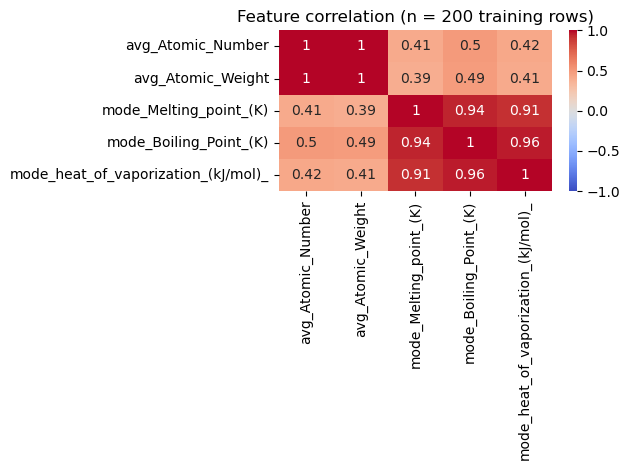

In [13]:
corr_matrix = X_train_subset.corr()  #correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f"Feature correlation (n = {N_TRAIN} training rows)")
plt.tight_layout()
plt.show()

There are many correlated features. In the full-dataset worksheet we left them in because there was
enough data for OLS to cope. Here, with a small training set, that same collinearity is one of the
reasons OLS will be unstable -- which is exactly what Ridge/Lasso/ElasticNet are designed to fix.

In [14]:
#Scale using only the small training set's mean/std -- exactly as you would in practice,
#you don't get to peek at the large pool when scaling in a real small-sample project.
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

## Linear Regression

In [15]:
# ---- Ordinary Least Squares (no regularization) ----
model_linear=LinearRegression()
model_linear.fit(X_train_scaled,y_train)

r2_linear_train=model_linear.score(X_train_scaled,y_train)
print(f"Linear regression: r^2 train: {r2_linear_train:.4f}")

Linear regression: r^2 train: 1.0000


In [16]:
r2_linear_test=model_linear.score(X_test_scaled,y_test)
print(f"Linear regression: r^2 test: {r2_linear_test:.4f}")

if N_TRAIN < N_FEATURES:
    print("\nNote: N_TRAIN < number of features, so this system is underdetermined --")
    print("OLS has enough freedom to fit the training data almost perfectly while")
    print("generalizing poorly. Watch the gap between train and test R^2 above.")

Linear regression: r^2 test: -9.1965

Note: N_TRAIN < number of features, so this system is underdetermined --
OLS has enough freedom to fit the training data almost perfectly while
generalizing poorly. Watch the gap between train and test R^2 above.


## Ridge Regression

In [17]:
# Ridge Regression model - with zero penalty should be similar to OLS

model_ridge = Ridge(alpha=0.0,solver='lsqr')
result_ridge = model_ridge.fit(X_train_scaled, y_train)

r2_ridge=model_ridge.score(X_train_scaled,y_train)
print(f"Ridge regression: r^2 train:{r2_ridge}")

r2_ridge_test=model_ridge.score(X_test_scaled,y_test)
print(f"Ridge regression: r^2 test: {r2_ridge_test}")

Ridge regression: r^2 train:0.9948567434475762
Ridge regression: r^2 test: -2.1109266336988397


In [18]:
model_ridge = Ridge(alpha=1.0)  #Try different values, 10, 100, 1000
result_ridge = model_ridge.fit(X_train_scaled, y_train)

r2_ridge=model_ridge.score(X_train_scaled,y_train)
print(f"Ridge regression: r^2 train:{r2_ridge}")

r2_ridge_test=model_ridge.score(X_test_scaled,y_test)
print(f"Ridge regression: r^2 test: {r2_ridge_test}")

Ridge regression: r^2 train:0.9506644252902773
Ridge regression: r^2 test: 0.5428591570817363


**To Summarize**

with alpha=1.0, r^2 train > r^2 test--> overfitting


| alpha | train r^2 | test r^2 |
|:--------:|:--------:|:--------:|
| 1.0 | 0.95 |0.54 |
| 10.0 | 0.91 |0.71|
|100.0 | 0.85 |0.73 |
| 1000.0 |0.73 | 0.68 |

In [19]:
# ---- Ridge regression, tuned by cross-validation ----
# A wide, log-spaced alpha grid -- the earlier worksheet only tried alpha = 0 and 1,
# which is too narrow a window to see the bias-variance tradeoff.
from sklearn.linear_model import RidgeCV

alphas_ridge = np.logspace(-3, 5, 50)

model_ridgecv = RidgeCV(alphas=alphas_ridge, scoring='r2', cv=5)
model_ridgecv.fit(X_train_scaled, y_train)  

best_alpha_ridge = model_ridgecv.alpha_
print(f"Best alpha for Ridge: {best_alpha_ridge:.5g}")

Best alpha for Ridge: 79.06


In [20]:
r2_ridge_train = model_ridgecv.score(X_train_scaled, y_train)
r2_ridge_test = model_ridgecv.score(X_test_scaled, y_test)

print(f"Ridge regression: r^2 train: {r2_ridge_train:.4f}")
print(f"Ridge regression: r^2 test:  {r2_ridge_test:.4f}")

Ridge regression: r^2 train: 0.8625
Ridge regression: r^2 test:  0.7354


## Lasso Regression

In [21]:
# Lasso Regression model

model_lasso = Lasso(alpha=0.001,max_iter=3000)  #Try different values, 
result_lasso = model_lasso.fit(X_train_scaled, y_train)

r2_lasso=model_lasso.score(X_train_scaled,y_train)
print(f"Lasso regression: r^2 train:{r2_lasso}")

r2_lasso_test=model_lasso.score(X_test_scaled,y_test)
print(f"Lasso regression: r^2 test: {r2_lasso_test}")

Lasso regression: r^2 train:0.9486788249248915
Lasso regression: r^2 test: 0.5612492044890824


with alpha=0.001, r^2 train > r^2 test--> overfitting


| alpha | train r^2 | test r^2 |
|:--------:|:--------:|:--------:|
| 0.001 | 0.95 |0.56 |
| 0.01 | 0.88 |0.74|
| 0.1 | 0.71 |0.69 |
| 0 |0.0 | -6.47 |

In [22]:
#Let's see what features have been set to zero

# Get the feature names 
feature_names = X.columns if isinstance(X, pd.DataFrame) else [f'feature_{i}' for i in range(X.shape[1])]


# Access Lasso model coefficients
lasso_coefficients = model_lasso.coef_

# Create a DataFrame of coefficients
lasso_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_coefficients
})

# Identify features with zero coefficient
zero_coef_features = lasso_coef_df[lasso_coef_df['Coefficient'] == 0]

print(f"Number of features with zero coefficient: {len(zero_coef_features)}")
print(zero_coef_features)


Number of features with zero coefficient: 138
                                    Feature  Coefficient
0                         avg_Atomic_Number         -0.0
1                         avg_Atomic_Weight         -0.0
3                                 avg_group         -0.0
5                                 avg_Metal          0.0
6                              avg_Nonmetal         -0.0
..                                      ...          ...
253  mode_1st_ionization_potential_(kJ/mol)         -0.0
255                  mode_Melting_point_(K)          0.0
258             mode_specific_heat_(J/g_K)_         -0.0
262           mode_heat_atomization(kJ/mol)          0.0
263                    mode_Cohesive_energy          0.0

[138 rows x 2 columns]


In [24]:
# ---- Lasso regression, tuned by cross-validation ----
from sklearn.linear_model import LassoCV

alphas_lasso = np.logspace(-4, 1, 50)

model_lassocv = LassoCV(alphas=alphas_lasso, cv=5, random_state=RANDOM_STATE, max_iter=50000,tol=1e-3, selection='random')

model_lassocv.fit(X_train_scaled, y_train)

best_alpha_lasso = model_lassocv.alpha_
print(f"Best alpha for Lasso: {best_alpha_lasso:.5g}")

Best alpha for Lasso: 0.02223


In [25]:
r2_lasso_train = model_lassocv.score(X_train_scaled, y_train)
r2_lasso_test = model_lassocv.score(X_test_scaled, y_test)

print(f"Lasso regression: r^2 train: {r2_lasso_train:.4f}")
print(f"Lasso regression: r^2 test: {r2_lasso_test:.4f}")

Lasso regression: r^2 train: 0.8425
Lasso regression: r^2 test: 0.7464


In [26]:
# ---- ElasticNet regression, tuned by cross-validation over both alpha and l1_ratio ----
from sklearn.linear_model import ElasticNetCV

alphas_elastic = np.logspace(-4, 1, 50)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]  # 0.1 ~ mostly Ridge-like, 0.99 ~ mostly Lasso-like

model_elasticcv = ElasticNetCV(alphas=alphas_elastic, l1_ratio=l1_ratios, cv=5,random_state=RANDOM_STATE, max_iter=50000, tol=1e-3, selection='random')

model_elasticcv.fit(X_train_scaled, y_train)

best_alpha_elastic = model_elasticcv.alpha_

best_l1_ratio = model_elasticcv.l1_ratio_

print(f"Best alpha for ElasticNet: {best_alpha_elastic:.5g}")
print(f"Best l1_ratio for ElasticNet: {best_l1_ratio}")

Best alpha for ElasticNet: 0.14563
Best l1_ratio for ElasticNet: 0.1


In [27]:
r2_elastic_train = model_elasticcv.score(X_train_scaled, y_train)
r2_elastic_test = model_elasticcv.score(X_test_scaled, y_test)

print(f"ElasticNet regression: r^2 train: {r2_elastic_train:.4f}")
print(f"ElasticNet regression: r^2 test:  {r2_elastic_test:.4f}")

ElasticNet regression: r^2 train: 0.8451
ElasticNet regression: r^2 test:  0.7381


In [28]:
# ---- Put all four models side by side ----
results = pd.DataFrame({
    'Model': ['Linear (OLS)', 'Ridge', 'Lasso', 'ElasticNet'],
    'Train R2': [r2_linear_train, r2_ridge_train, r2_lasso_train, r2_elastic_train],
    'Test R2':  [r2_linear_test,  r2_ridge_test,  r2_lasso_test,  r2_elastic_test],
})
results['Train - Test gap'] = results['Train R2'] - results['Test R2']
results

,Model,Train R2,Test R2,Train - Test gap
0,Linear (OLS),1.000000,-9.196522,10.196522
1,Ridge,0.862487,0.735418,0.127069
2,Lasso,0.842532,0.746443,0.096089
3,ElasticNet,0.845063,0.738132,0.106931


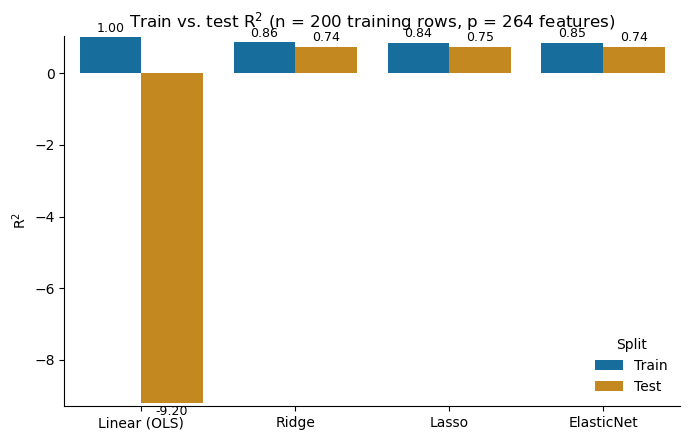

In [29]:
# ---------------------------------------------------------------------------
# Chart 1: Train vs. test R^2 per model -- the headline overfitting story
# ---------------------------------------------------------------------------
model_order = ['Linear (OLS)', 'Ridge', 'Lasso', 'ElasticNet']

results_long = results.melt(id_vars='Model', value_vars=['Train R2', 'Test R2'],
                             var_name='Split', value_name='R2')
results_long['Split'] = results_long['Split'].str.replace(' R2', '', regex=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=results_long, x='Model', y='R2', hue='Split',
            order=model_order, hue_order=['Train', 'Test'],
            palette=sns.color_palette('colorblind', 2), ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=9)

ax.set_ylim(min(0, results_long['R2'].min() - 0.1), 1.05)
ax.set_ylabel('R$^2$')
ax.set_xlabel('')
ax.set_title(f'Train vs. test R$^2$ (n = {N_TRAIN} training rows, p = {N_FEATURES} features)')
ax.legend(title='Split', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

In [30]:
#What to look for:
#- OLS: a large gap between train and test R^2 -- classic overfitting when n is small relative to p.
#- Ridge: the gap shrinks because the penalty shrinks all coefficients together.
#- Lasso / ElasticNet: the gap shrinks further, and (next section) does so by zeroing out
#  entire descriptors rather than just shrinking every coefficient a little.

In [35]:
# ---------------------------------------------------------------------------
# Chart 2: the regularization path -- R^2 vs. alpha for Ridge and Lasso
# ---------------------------------------------------------------------------
# RidgeCV/LassoCV only hand back the single best alpha. To see *why* it's best,
# we refit across the whole alpha grid and track train/test R^2 at each value.
def r2_path(model_cls, alphas, **kwargs):
    train_scores, test_scores = [], []
    for a in alphas:
        m = model_cls(alpha=a, **kwargs)
        m.fit(X_train_scaled, y_train)
        train_scores.append(m.score(X_train_scaled, y_train))
        test_scores.append(m.score(X_test_scaled, y_test))
    return np.array(train_scores), np.array(test_scores)

ridge_train_path, ridge_test_path = r2_path(Ridge, alphas_ridge)
lasso_train_path, lasso_test_path = r2_path(Lasso, alphas_lasso, max_iter=30000)

C:\Users\Sasani\AppData\Local\anaconda3\envs\mle5217\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.022e+00, tolerance: 2.398e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\Sasani\AppData\Local\anaconda3\envs\mle5217\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.905e-01, tolerance: 2.398e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\Sasani\AppData\Local\anaconda3\envs\mle5217\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of 

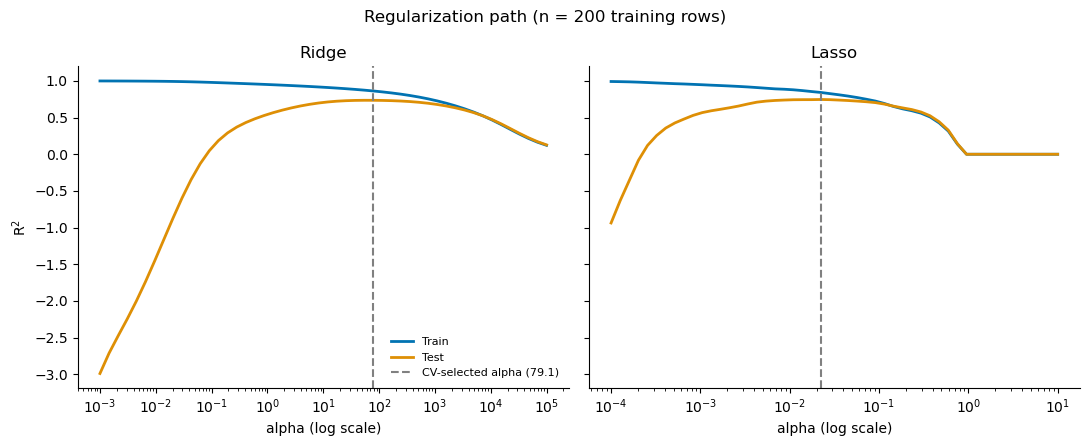

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
colors = sns.color_palette('colorblind', 2)

for ax, alphas, train_path, test_path, best_alpha, name in [
    (axes[0], alphas_ridge, ridge_train_path, ridge_test_path, best_alpha_ridge, 'Ridge'),
    (axes[1], alphas_lasso, lasso_train_path, lasso_test_path, best_alpha_lasso, 'Lasso'),
]:
    ax.plot(alphas, train_path, color=colors[0], lw=2, label='Train')
    ax.plot(alphas, test_path, color=colors[1], lw=2, label='Test')
    ax.axvline(best_alpha, color='gray', ls='--', lw=1.5,
               label=f'CV-selected alpha ({best_alpha:.3g})')
    ax.set_xscale('log')
    ax.set_xlabel('alpha (log scale)')
    ax.set_title(name)
    sns.despine(ax=ax)

axes[0].set_ylabel('R$^2$')
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f'Regularization path (n = {N_TRAIN} training rows)')
plt.tight_layout()
plt.show()

In [37]:
#What to look for:
#- At very small alpha, both curves behave like OLS: high train R^2, weaker test R^2.
#- As alpha grows, train R^2 falls (more bias) while test R^2 rises, then falls (too much bias).
#- The dashed line is the alpha cross-validation picked -- it should sit near the test R^2 peak.

In [38]:
# ---------------------------------------------------------------------------
# Chart 3: sparsity -- how many descriptors does each model actually keep?
# ---------------------------------------------------------------------------
feature_names = X.columns

coef_table = pd.DataFrame({
    'Linear (OLS)': model_linear.coef_,
    'Ridge': model_ridgecv.coef_,
    'Lasso': model_lassocv.coef_,
    'ElasticNet': model_elasticcv.coef_,
}, index=feature_names)

def count_nonzero(coefs, tol=1e-6):
    return int(np.sum(np.abs(coefs) > tol))

nonzero_counts = coef_table.apply(count_nonzero).reindex(model_order)
kept_vs_total = pd.DataFrame({
    'Features kept': nonzero_counts,
    'Features zeroed': N_FEATURES - nonzero_counts,
})
kept_vs_total

,Features kept,Features zeroed
Linear (OLS),263,1
Ridge,263,1
Lasso,48,216
ElasticNet,106,158


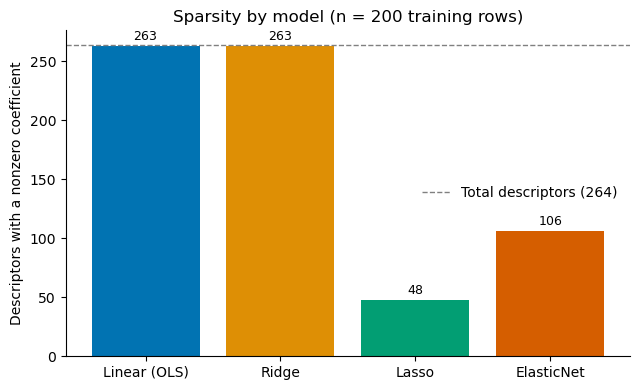

In [39]:
fig, ax = plt.subplots(figsize=(6.5, 4))
model_colors = dict(zip(model_order, sns.color_palette('colorblind', 4)))
bars = ax.bar(kept_vs_total.index, kept_vs_total['Features kept'],
              color=[model_colors[m] for m in kept_vs_total.index])
ax.bar_label(bars, fmt='%d', padding=2, fontsize=9)
ax.axhline(N_FEATURES, color='gray', ls='--', lw=1, label=f'Total descriptors ({N_FEATURES})')
ax.set_ylabel('Descriptors with a nonzero coefficient')
ax.set_title(f'Sparsity by model (n = {N_TRAIN} training rows)')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

In [40]:
#Ridge shrinks every coefficient a little but essentially never sets one exactly to zero --
#it keeps (close to) all descriptors. Lasso and ElasticNet, by contrast, use their L1 term
#to zero out whole descriptors, which is a form of automatic feature selection. Let's look
#at which descriptors Lasso decided actually matter for formation energy.

In [41]:
#Descriptors Lasso kept, sorted by the size of their (scaled) coefficient
lasso_kept = coef_table['Lasso'][coef_table['Lasso'].abs() > 1e-6]
lasso_kept.reindex(lasso_kept.abs().sort_values(ascending=False).index).head(15)

dev_Pauling_Electronegativity                 -0.227754
max_heat_of_vaporization_(kJ/mol)_            -0.188702
dev_heat_atomization(kJ/mol)                   0.186031
avg_l_quantum_number                          -0.149176
mode_polarizability(A^3)                       0.143509
mode_Allred-Rockow_electronegativity          -0.140838
dev_Gordy_electonegativity                    -0.132388
avg_metallic_valence                           0.114809
max_Zunger_radii_sum                          -0.103289
dev_Covalent_Radius                            0.093697
range_Allred-Rockow_electronegativity         -0.091231
dev_valence_d                                  0.083177
min_Number_of_unfilled_d_valence_electrons    -0.080863
range_group                                   -0.076808
mode_Number_of_unfilled_f_valence_electrons   -0.076061
Name: Lasso, dtype: float64

In [42]:
#This is the physically interpretable payoff of Lasso/ElasticNet: rather than a black-box
#coefficient on all 264 descriptors, you get a short, ranked list of the elemental properties
#(via the Oliynyk representation) that the model actually relies on to predict formation energy --
#worth checking against chemical intuition (e.g. electronegativity- and radius-related descriptors
#are common drivers of formation energy).

In [43]:
# ---------------------------------------------------------------------------
# Try it yourself
# ---------------------------------------------------------------------------
#Go back to the N_TRAIN cell near the top and re-run the notebook with:
#  N_TRAIN = 150   (fewer rows than descriptors -- the most dramatic overfitting)
#  N_TRAIN = 300   (n roughly equal to p)
#  N_TRAIN = 2000  (n starting to dominate p again)
#  N_TRAIN = 20000 (should look close to the original, full-dataset worksheet)
#
#Compare against the original worksheet (run on the full ~44,000-row training set) to see
#how the same four models, on the same descriptors, tell a completely different story once
#n stops being much larger than p.